# About Dataset

## SPAM E-mail Database

The “spam” concept is diverse: advertisements for products/websites, make money fast schemes, chain letters, pornography… Our collection of spam e-mails came from our postmaster and individuals who had filed spam. Our collection of non-spam e-mails came from filed work and personal e-mails, and hence the word ‘george’ and the area code ‘650’ are indicators of non-spam. These are useful when constructing a personalized spam filter. One would either have to blind such non-spam indicators or get a very wide collection of non-spam to generate a general purpose spam filter.

Attribute Information:

The last column denotes whether the e-mail was considered spam (1) or not (0), i.e. unsolicited commercial e-mail. Most of the attributes indicate whether a particular word or character was frequently occurring in the e-mail. The run-length attributes (55-57) measure the length of sequences of consecutive capital letters.

For the statistical measures of each attribute, see the end of this file. Here are the definitions of the attributes:

48 continuous real [0,100] attributes of type word_freq_WORD = percentage of words in the e-mail that match WORD, i.e. 100 * (number of times the WORD appears in the e-mail) / total number of words in e-mail. A “word” in this case is any string of alphanumeric characters bounded by non-alphanumeric characters or end-of-string.

6 continuous real [0,100] attributes of type char_freq_CHAR = percentage of characters in the e-mail that match CHAR, i.e. 100 * (number of CHAR occurrences) / total characters in e-mail

1 continuous real [1,…] attribute of type capital_run_length_average = average length of uninterrupted sequences of capital letters

1 continuous integer [1,…] attribute of type capital_run_length_longest = length of longest uninterrupted sequence of capital letters

1 continuous integer [1,…] attribute of type capital_run_length_total = sum of length of uninterrupted sequences of capital letters = total number of capital letters in the e-mail

1 nominal {0,1} class attribute of type spam = denotes whether the e-mail was considered spam (1) or not (0), i.e. unsolicited commercial e-mail.

In [1]:
#Import libraries
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## Load and Inspect the Dataset

The dataset is loaded from the CSV file and its structure is inspected before modeling.

In [2]:
DATA_PATH = "spambase.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nFirst 10 rows:")
print(df.head(10).to_string(index=False))
print("\nLast 10 rows:")
print(df.tail(10).to_string(index=False))
print("\nColumn data types:")
print(df.dtypes)
print("\nDataset loaded successfully.")

Dataset shape: (4601, 58)

First 10 rows:
 word_freq_make  word_freq_address  word_freq_all  word_freq_3d  word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  word_freq_order  word_freq_mail  word_freq_receive  word_freq_will  word_freq_people  word_freq_report  word_freq_addresses  word_freq_free  word_freq_business  word_freq_email  word_freq_you  word_freq_credit  word_freq_your  word_freq_font  word_freq_000  word_freq_money  word_freq_hp  word_freq_hpl  word_freq_george  word_freq_650  word_freq_lab  word_freq_labs  word_freq_telnet  word_freq_857  word_freq_data  word_freq_415  word_freq_85  word_freq_technology  word_freq_1999  word_freq_parts  word_freq_pm  word_freq_direct  word_freq_cs  word_freq_meeting  word_freq_original  word_freq_project  word_freq_re  word_freq_edu  word_freq_table  word_freq_conference  char_freq_%3B  char_freq_%28  char_freq_%5B  char_freq_%21  char_freq_%24  char_freq_%23  capital_run_length_average  capital_run_length_longest  capit

## Data Cleaning and Preprocessing

The identifier column is removed, duplicate rows are dropped, and missing values are checked.

In [ ]:
initial_shape = df.shape

before_duplicates = df.shape[0]
df = df.drop_duplicates()
after_duplicates = df.shape[0]
removed_duplicates = before_duplicates - after_duplicates

missing_values = df.isnull().sum()

print("Duplicate rows removed:", removed_duplicates)
print("\nMissing values per column:")
print(missing_values)

Shape after dropping UDI: (4210, 58)
Duplicate rows removed: 391

Missing values per column:
word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_l

## Exploratory Data Analysis

A quick statistical and visual summary is created to understand the data distribution and relationships with the target.

In [6]:
print('Shape:', df.shape)

Shape: (4210, 59)


In [7]:
print('Head')
print(df.head)
print('Tail')
print(df.tail)

Head
<bound method NDFrame.head of       word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0               0.00               0.64           0.64           0.0   
1               0.21               0.28           0.50           0.0   
2               0.06               0.00           0.71           0.0   
3               0.00               0.00           0.00           0.0   
4               0.00               0.00           0.00           0.0   
...              ...                ...            ...           ...   
4596            0.31               0.00           0.62           0.0   
4597            0.00               0.00           0.00           0.0   
4598            0.30               0.00           0.30           0.0   
4599            0.96               0.00           0.00           0.0   
4600            0.00               0.00           0.65           0.0   

      word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0              0.32    

In [9]:
print(df.dtypes)

word_freq_make                float64
word_freq_address             float64
word_freq_all                 float64
word_freq_3d                  float64
word_freq_our                 float64
word_freq_over                float64
word_freq_remove              float64
word_freq_internet            float64
word_freq_order               float64
word_freq_mail                float64
word_freq_receive             float64
word_freq_will                float64
word_freq_people              float64
word_freq_report              float64
word_freq_addresses           float64
word_freq_free                float64
word_freq_business            float64
word_freq_email               float64
word_freq_you                 float64
word_freq_credit              float64
word_freq_your                float64
word_freq_font                float64
word_freq_000                 float64
word_freq_money               float64
word_freq_hp                  float64
word_freq_hpl                 float64
word_freq_ge

/var/folders/bs/0dgg3xzx0gn8v4gn7_6k83xh0000gn/T/ipykernel_4909/3392986869.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spam_counts.index.map(spam_labels), y=spam_counts.values, ax=ax, palette=["#4C78A8", "#F58518"])


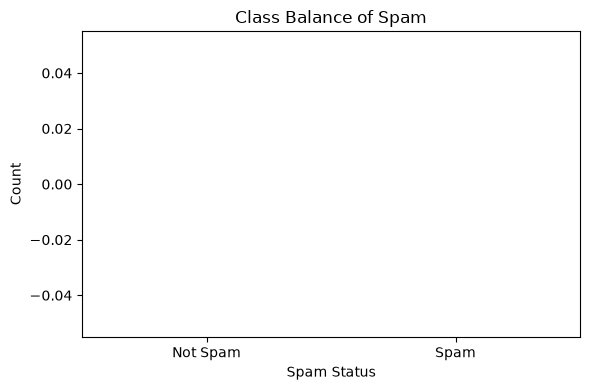

Observation: The dataset is heavily imbalanced, with far fewer failure cases than non-failure cases.
Observation: The numeric features show modest correlations with failure, which supports building a model that can capture nonlinear patterns.


In [1]:
# Full exploratory data analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the dataset is available even if earlier cells were not executed yet
if "df" not in globals():
    DATA_PATH = "spambase.csv"
    df = pd.read_csv(DATA_PATH)
    df = df.drop_duplicates()

# Univariate analysis
spam_labels = {0: "Not Spam", 1: "Spam"}

df["spam"] = df["class"].map(spam_labels)

# 1) Class balance of Spam
spam_counts = df["spam"].value_counts().reindex([0, 1])
spam_percentages = (spam_counts / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=spam_counts.index.map(spam_labels), y=spam_counts.values, ax=ax, palette=["#4C78A8", "#F58518"])
for bar, pct in zip(ax.patches, spam_percentages.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20, f"{pct:.1f}%", ha="center", va="bottom")
ax.set_title("Class Balance of Spam")
ax.set_xlabel("Spam Status")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()
print("Observation: The dataset is heavily imbalanced, with far fewer failure cases than non-failure cases.")

# # 2) Product type count plot
# fig, ax = plt.subplots(figsize=(7, 4))
# sns.countplot(data=df, x="Type", order=df["Type"].value_counts().index, palette="Set2", ax=ax)
# ax.set_title("Product Type Distribution")
# ax.set_xlabel("Product Type")
# ax.set_ylabel("Count")
# for container in ax.containers:
#     ax.bar_label(container, fmt="%d", padding=3)
# plt.tight_layout()
# plt.show()
# print("Observation: Product type L is the most common category, while type H appears less frequently.")

# # 3) Histograms for the five numeric sensors
# sensor_cols = ["Air temperature", "Process temperature", "Rotational speed", "Torque", "Tool wear"]
# fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# axes = axes.flatten()

# for ax, col in zip(axes, sensor_cols):
#     sns.histplot(df[col], bins=30, kde=True, color="#4C78A8", ax=ax)
#     ax.set_title(f"Distribution of {col}")
#     ax.set_xlabel(col)
#     ax.set_ylabel("Frequency")

# # Hide the last unused subplot
# axes[-1].axis("off")
# plt.tight_layout()
# plt.show()
# print("Observation: The sensor variables show varied distributions, with some being fairly symmetric and others skewed.")

# # Bivariate analysis
# # 4) Boxplots for selected numeric features by failure status
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# for ax, col in zip(axes, ["Torque", "Tool wear", "Rotational speed"]):
#     sns.boxplot(data=df, x="Failure Label", y=col, palette=["#4C78A8", "#F58518"], ax=ax)
#     ax.set_title(f"{col} by Failure Status")
#     ax.set_xlabel("Failure Status")
#     ax.set_ylabel(col)
# plt.tight_layout()
# plt.show()
# print("Observation: The failure group tends to differ from the non-failure group in these sensor distributions, suggesting useful separation signals.")

# # 5) Failure rate within each product type
# failure_rate_by_type = (df.groupby("Type")["Failure"].mean() * 100).sort_values(ascending=False)
# fig, ax = plt.subplots(figsize=(7, 4))
# sns.barplot(x=failure_rate_by_type.index, y=failure_rate_by_type.values, palette="Set2", ax=ax)
# ax.set_title("Failure Rate (%) by Product Type")
# ax.set_xlabel("Product Type")
# ax.set_ylabel("Failure Rate (%)")
# for bar, val in zip(ax.patches, failure_rate_by_type.values):
#     ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f"{val:.1f}%", ha="center", va="bottom")
# plt.tight_layout()
# plt.show()
# print("Observation: Failure rates vary across product types, indicating that product type may carry predictive information.")

# # 6) Correlation heatmap of numeric columns and Failure
# numeric_cols = ["Air temperature", "Process temperature", "Rotational speed", "Torque", "Tool wear", "Failure"]
# correlation_matrix = df[numeric_cols].corr()

# fig, ax = plt.subplots(figsize=(8, 6))
# sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, ax=ax)
# ax.set_title("Correlation Heatmap of Numeric Features and Failure")
# plt.tight_layout()
plt.show()
print("Observation: The numeric features show modest correlations with failure, which supports building a model that can capture nonlinear patterns.")